____
# Sea state dependency


In [32]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [21]:
dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

In [7]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [base_dic]
l = ['L3-2km',]
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [base_dic]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((DS.ggde<1.5e-4) & (DS.ggdn<1.5e-4), drop=True)
DS = DS.where(DS.distance_to_coast>10e3, drop=True)

# Closure figs
ds = compute_mean_square(DS)/U2
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


_______
# Compute and project (x = cross, y = alg)

In [8]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy
    
DSr =  crossalg_proj(DS)  

In [9]:
DSr

<xarray.Dataset> Size: 98MB
Dimensions:            (id_comb: 1, row_number: 291625)
Coordinates: (12/13)
    datetime           (id_comb, row_number) datetime64[ns] 2MB 2023-04-01T11...
    longitude          (id_comb, row_number) float64 2MB 5.538 5.539 ... 1.895
    latitude           (id_comb, row_number) float64 2MB 42.31 42.31 ... 39.08
    pass_number        (id_comb, row_number) int64 2MB 3 3 3 3 3 ... 16 16 16 16
    time_to_swot       (id_comb, row_number) timedelta64[ns] 2MB 11:52:32.696...
    cycle_number       (id_comb, row_number) int64 2MB 478 478 478 ... 577 577
    ...                 ...
    drifter_type       (id_comb, row_number) object 2MB 'CARTHE' ... 'SVP-B'
    depth              (id_comb, row_number) int64 2MB 0 0 0 0 0 ... 15 15 15 15
    phi                (id_comb, row_number) float64 2MB 0.2477 0.2478 ... 2.912
    distance_to_coast  (row_number) float64 2MB 8.606e+04 8.606e+04 ... 2.43e+04
  * row_number         (row_number) int64 2MB 144 145 146 ... 376577 376578
  * id_comb            (id_comb) <U6 24B 'L3-2km'
Data variables: (12/30)
    sumx               (id_comb, row_number) float64 2MB -2.347e-05 ... -4.52...
    sumy               (id_comb, row_number) float64 2MB -5.273e-06 ... -1.17...
    accx               (id_comb, row_number) float64 2MB -8.189e-06 ... 1.231...
    accy               (id_comb, row_number) float64 2MB 1.401e-07 ... -3.153...
    corx               (id_comb, row_number) float64 2MB 8.297e-06 ... -1.162...
    cory               (id_comb, row_number) float64 2MB 1.721e-05 ... -3.143...
    ...                 ...
    prody_acc_cor      (id_comb, row_number) float64 2MB 2.412e-12 ... 9.91e-12
    prody_acc_ggd      (id_comb, row_number) float64 2MB -4.351e-13 ... -6.46...
    prody_acc_wd       (id_comb, row_number) float64 2MB -2.735e-12 ... 1.305...
    prody_cor_ggd      (id_comb, row_number) float64 2MB -5.345e-11 ... -6.43...
    prody_cor_wd       (id_comb, row_number) float64 2MB -3.361e-10 ... 1.3e-13
    prody_ggd_wd       (id_comb, row_number) float64 2MB 6.062e-11 ... -8.477...

In [19]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    #da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    #ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

/dev/shm/pbs.2770549.datarmor0/ipykernel_37235/2910541907.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


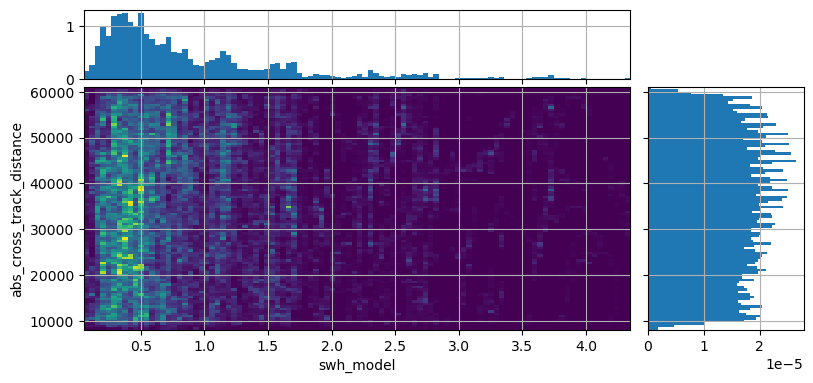

In [24]:
dfr = DSr.to_dataframe().reset_index().set_index('row_number')
dfs = pd.read_csv(os.path.join(zarr_dir, 'coloc_files', 'alti',f'alticoloc_{alti_product_key}_general_'+colocs_sources+'.csv')).set_index('row_number')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])

dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert']], dfr], axis=1).dropna()

dss = dfrr.to_xarray()
plot_join_pdfs(dss, 'swh_model', 'abs_cross_track_distance', binx=100, biny=100)

_________
# Regular bins

In [25]:
compute_error = 'centrallimit'

dfswh = dfrr[(dfrr.abs_cross_track_distance>20e3) & (dfrr.abs_cross_track_distance<50e3)]
swh_dist_bins = np.linspace(0, 4, 10)
dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
dsswh = compute_mean_square_groupby(dfswh, groupby = 'swh_model_cut', dirname = ('x', 'y'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsswh['meanbin_abs_cross_track_distance'] = dfswh.groupby('swh_model_cut', observed=False).abs_cross_track_distance.mean().dropna().to_xarray()
dsswh = dsswh.where(dsswh.nb_coloc>0).dropna('swh_model_cut')

/dev/shm/pbs.2770549.datarmor0/ipykernel_37235/1795422111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)


/dev/shm/pbs.2770549.datarmor0/ipykernel_37235/1813606424.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['GGDxu'] = dfswh.ggdx**2/U2
/dev/shm/pbs.2770549.datarmor0/ipykernel_37235/1813606424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['GGDyu'] = dfswh.ggdy**2/U2
/dev/shm/pbs.2770549.datarmor0/ipykernel_37235/1813606424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

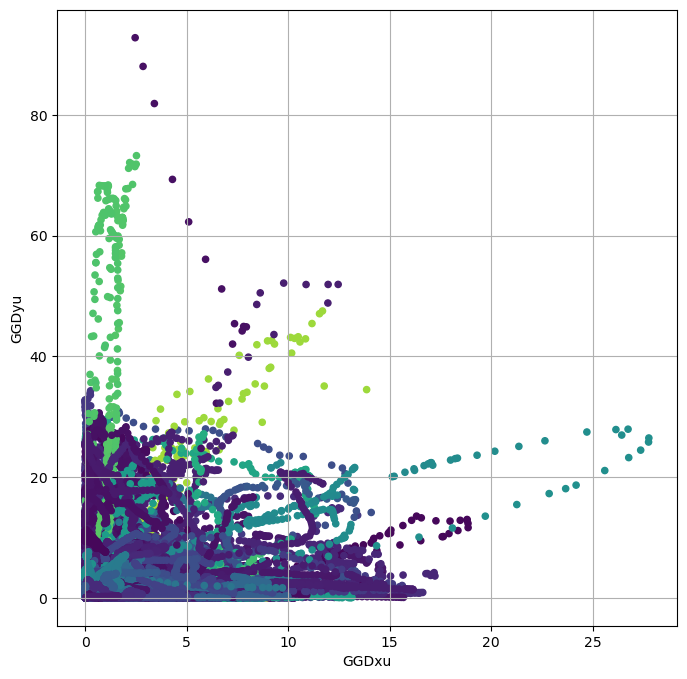

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dfswh['GGDxu'] = dfswh.ggdx**2/U2
dfswh['GGDyu'] = dfswh.ggdy**2/U2
dfswh['GGD'] = dfswh.GGDxu + dfswh.GGDyu
dfswh.plot.scatter('GGDxu', 'GGDyu', c = dfswh.swh_model, ax=ax)
ax.grid()

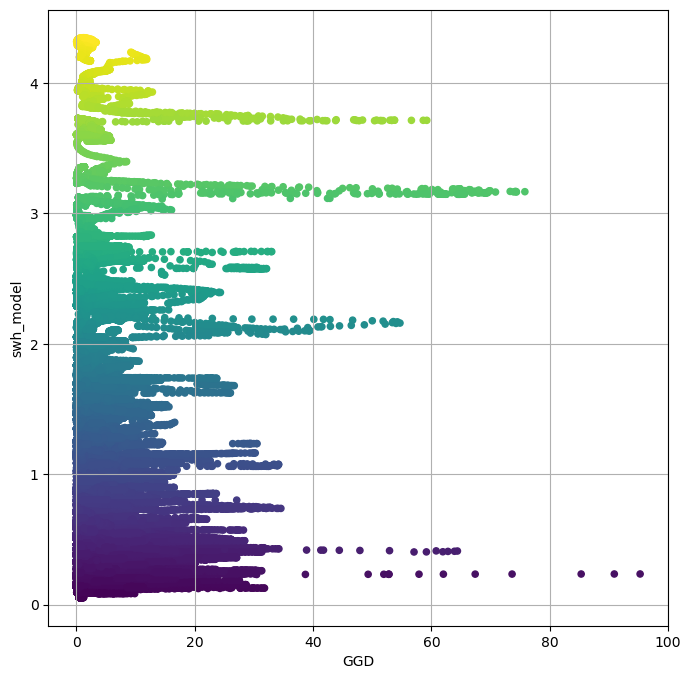

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dfswh.plot.scatter('GGD', 'swh_model', c = dfswh.swh_model, ax=ax)
ax.grid()

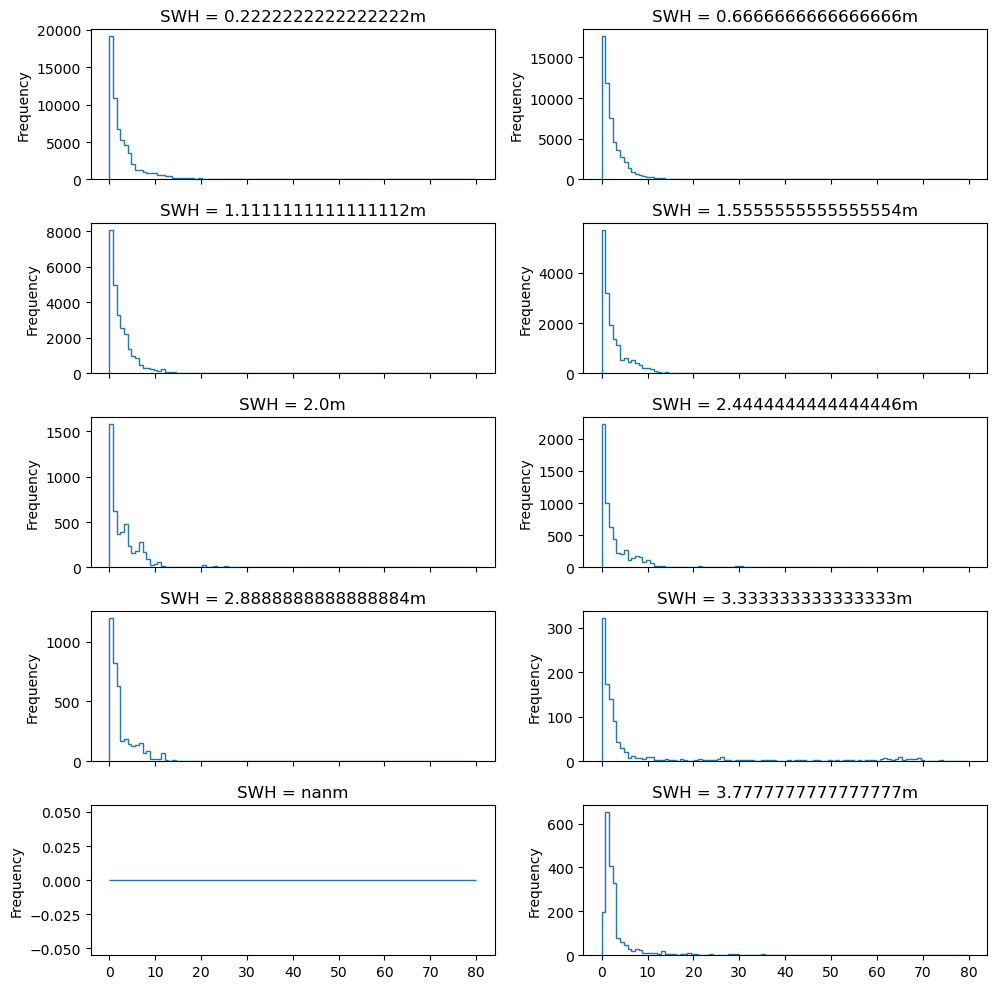

In [28]:
fig, axs = plt.subplots(5, 2, figsize=(10,10), frameon=False, sharex=True)
axs = axs.flatten()
i=0
for swh in sorted(dfswh.swh_model_cut.unique()) :
    ax=axs[i]
    df_ = dfswh[dfswh.swh_model_cut==swh]
    df_.GGD.plot.hist(bins = np.linspace(0,80,100), histtype='step', ax=ax)
    ax.set_title(f'SWH = {swh}m')
    i+=1

fig.tight_layout()
#dfswh.groupby('swh_model_cut').GGD.plot.hist(bins = np.linspace(0,80,100), histtype='step', subplots=False)

In [31]:
fig = plt.figure(figsize=(7,7), frameon=False)
ax = fig.add_subplot(111, projection=ccrs.Orthographic(3, 40.5))
ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)

dfswh[dfswh.GGD>30].plot.scatter('longitude', 'latitude', c='swh_model', ax=ax, transform=crs, s=1)

<GeoAxes: xlabel='longitude', ylabel='latitude'>

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Error in callback <function _draw_all_if_interactive at 0x2aaae3420700> (for post_execute):


URLError: <urlopen error [Errno 101] Network is unreachable>

URLError: <urlopen error [Errno 101] Network is unreachable>

<Figure size 700x700 with 2 Axes>

(0.0, 4.0)

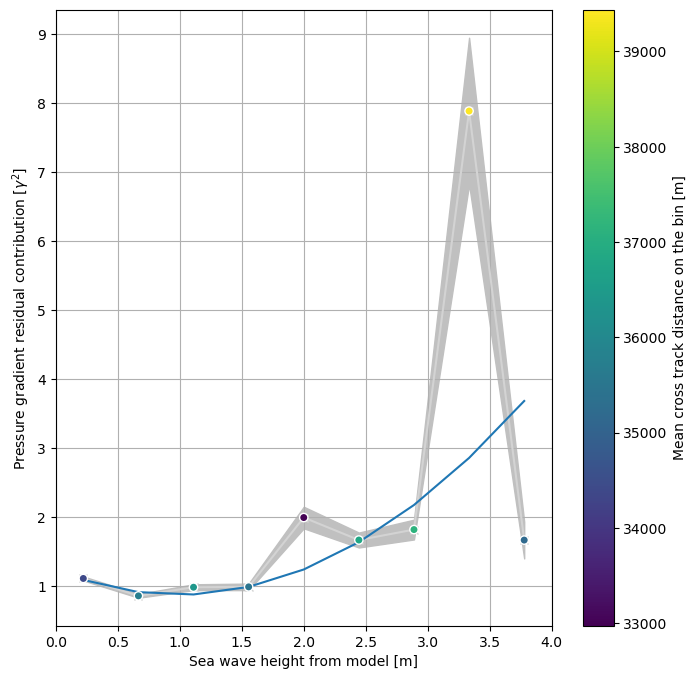

In [33]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['ser__E_ggd'] = dsswh.ser__Ex_ggd + dsswh.ser__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ser__')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')

c = dsswh.where(dsswh.swh_model_cut<2).swh_model_cut
coef = np.polyfit(c, dsswh.E_ggd,2, w =dsswh.nb_coloc )
ax.plot(c, coef[0]*c**2  +coef[1]*c +coef[2])


ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')
ax.set_xlim(0, 4)

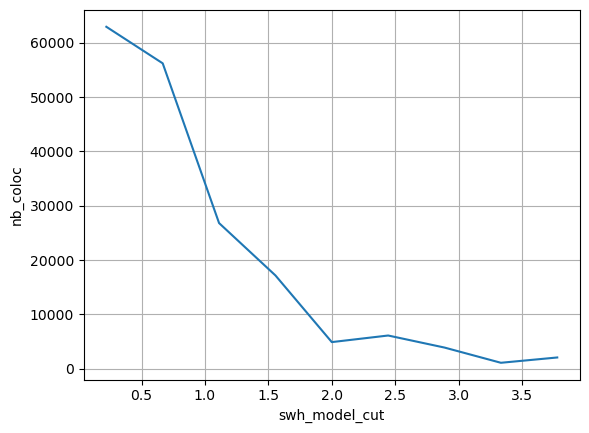

In [34]:
dsswh.nb_coloc.plot()
plt.grid()


Text(0.5, 0, 'Sea wave height from model [m]')

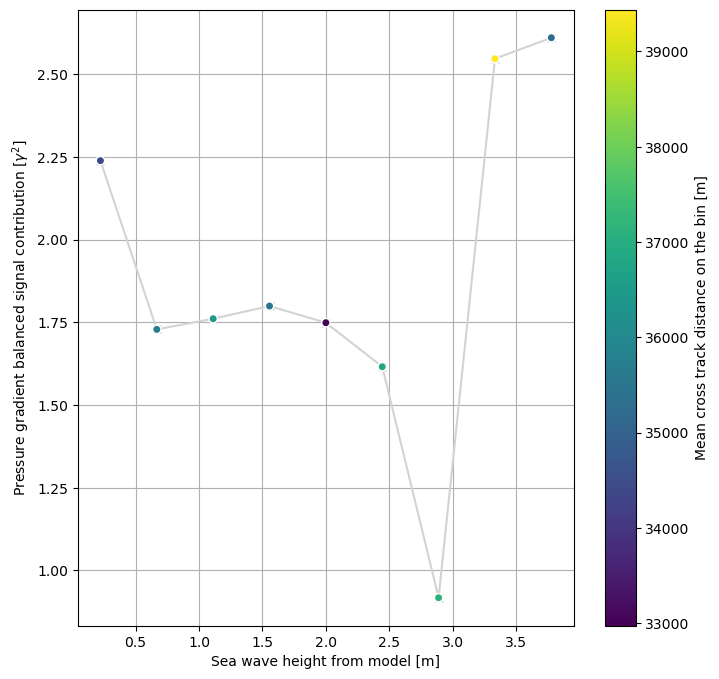

In [35]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['B_ggd'] = dsswh.Bx_ggd + dsswh.By_ggd
#dsswh['ber__B_ggd'] = dsswh.ber__Bx_ggd + dsswh.ber__By_ggd
dsswh.B_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
#plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='B_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')



ax.grid()
ax.set_ylabel(r'Pressure gradient balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

# Same-nb bins

In [36]:
compute_error = 'centrallimit'
n=25
dfswh = dfrr[(dfrr.abs_cross_track_distance>20e3) & (dfrr.abs_cross_track_distance<50e3)]
swh_dist_bins = np.array([float(dfswh.swh_model.quantile(i/n)) for i in range(n+1)])
dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
dsswh = compute_mean_square_groupby(dfswh, groupby = 'swh_model_cut', dirname = ('x', 'y'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsswh['meanbin_abs_cross_track_distance'] = dfswh.groupby('swh_model_cut', observed=False).abs_cross_track_distance.mean().dropna().to_xarray()
dsswh = dsswh.where(dsswh.nb_coloc>0).dropna('swh_model_cut')

/dev/shm/pbs.2770549.datarmor0/ipykernel_37235/206469896.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)


(0.0, 4.0)

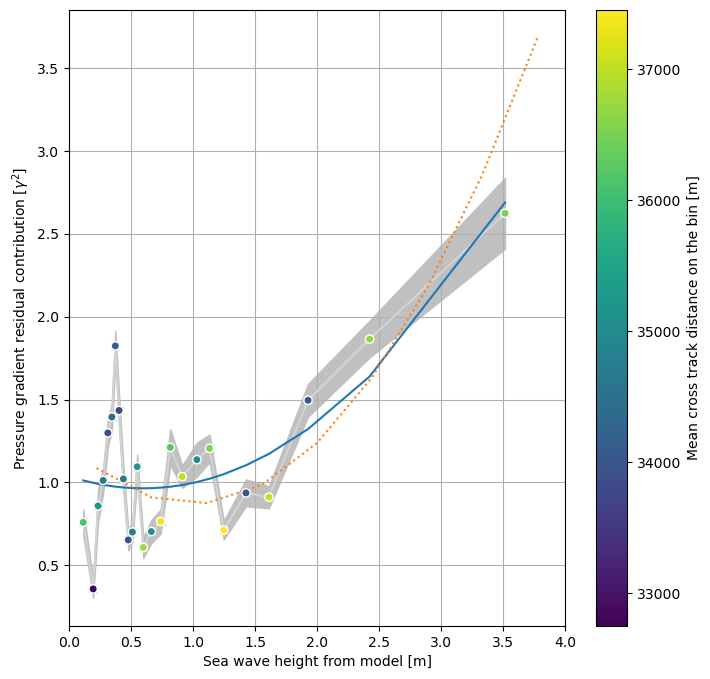

In [37]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['ser__E_ggd'] = dsswh.ser__Ex_ggd + dsswh.ser__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ser__')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')

c1 = dsswh.where(dsswh.swh_model_cut<2).swh_model_cut
coef1 = np.polyfit(c1, dsswh.E_ggd,2, w =dsswh.nb_coloc )
ax.plot(c1, coef1[0]*c1**2  +coef1[1]*c1 +coef1[2])
ax.plot(c, coef[0]*c**2  +coef[1]*c +coef[2], ls=':')

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

ax.set_xlim(0, 4)

(0.0, 4.0)

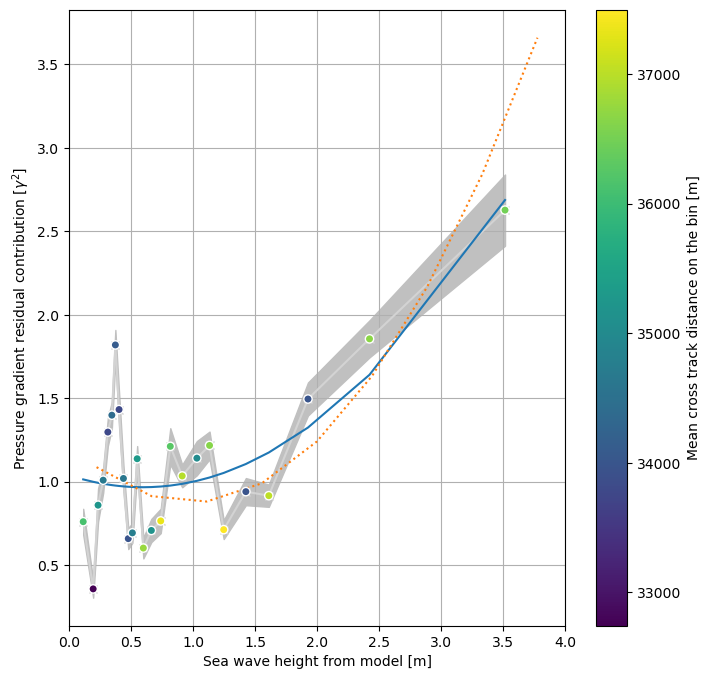

In [18]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['ser__E_ggd'] = dsswh.ser__Ex_ggd + dsswh.ser__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ser__')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')

c1 = dsswh.where(dsswh.swh_model_cut<2).swh_model_cut
coef1 = np.polyfit(c1, dsswh.E_ggd,2, w =dsswh.nb_coloc )
ax.plot(c1, coef1[0]*c1**2  +coef1[1]*c1 +coef1[2])
ax.plot(c, coef[0]*c**2  +coef[1]*c +coef[2], ls=':')

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

ax.set_xlim(0, 4)

(6000.0, 7500.0)

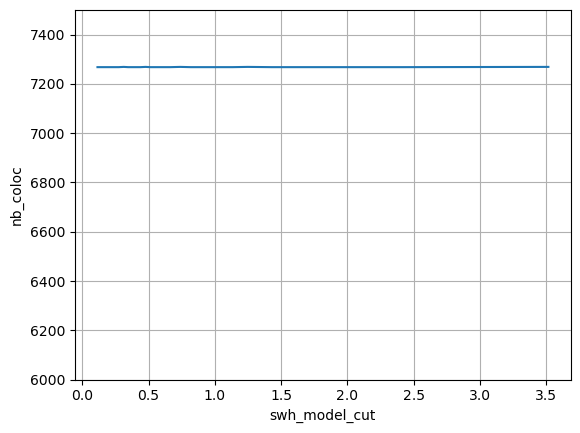

In [38]:
dsswh.nb_coloc.plot()
plt.grid()
plt.ylim(6000, 7500)

Text(0.5, 0, 'Sea wave height from model [m]')

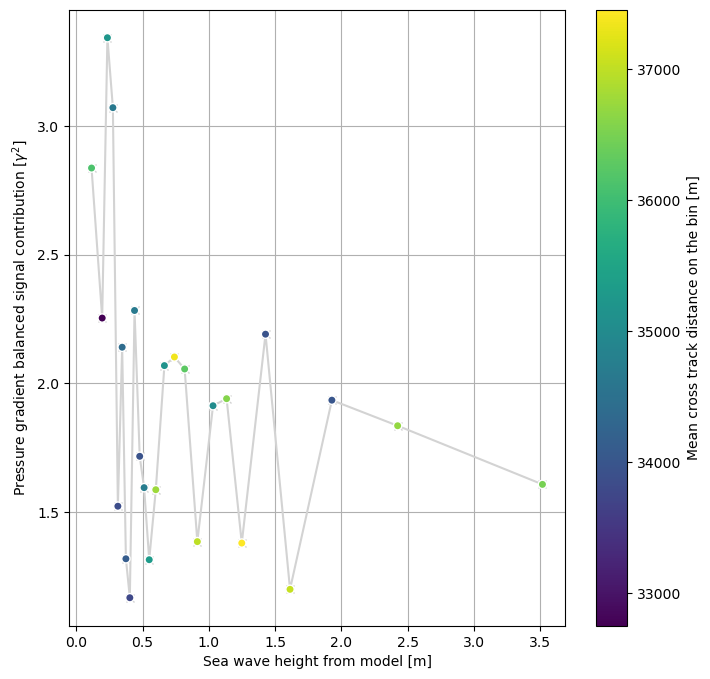

In [39]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['B_ggd'] = dsswh.Bx_ggd + dsswh.By_ggd
#dsswh['ber__B_ggd'] = dsswh.ber__Bx_ggd + dsswh.ber__By_ggd
dsswh.B_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
#plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='B_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')



ax.grid()
ax.set_ylabel(r'Pressure gradient balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')